In [14]:
import os
import json

from glob import glob

import climlab
import torch
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [15]:
BASE_DIR = "/gws/ssde/j25a/ai4er/users/pn341/climate-rl-cc"
RECORDS_DIR = f"{BASE_DIR}/records"
DATASETS_DIR = f"{BASE_DIR}/datasets"
IMGS_DIR = f"{BASE_DIR}/results/imgs"  
PLOTTING_DATA_DIR = f"{BASE_DIR}/results/data" 

EXP_ID = "ebm-v1-cc"

NUM_STEPS = 200
EBM_LATITUDES = 96

DELTA_A = 4.0

In [16]:
fp_Ts = f"{DATASETS_DIR}/skt.sfc.mon.1981-2010.ltm.nc"
ncep_url = "http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.reanalysis.derived/"


def download_and_save_dataset(url, filepath, dataset_name):
    if not os.path.exists(filepath):
        print(f"Downloading {dataset_name} data ...")
        dataset = xr.open_dataset(url, decode_times=False)
        dataset.to_netcdf(filepath, format="NETCDF3_64BIT")
        print(f"{dataset_name} data saved to {filepath}")
    else:
        print(f"Loading {dataset_name} data ...")
        dataset = xr.open_dataset(
            filepath,
            decode_times=xr.coders.CFDatetimeCoder(use_cftime=True),
        )
    return dataset


ncep_Ts = download_and_save_dataset(
    ncep_url + "surface_gauss/skt.sfc.mon.1981-2010.ltm.nc",
    fp_Ts,
    "NCEP surface temperature",
).sortby("lat")

lat_ncep = ncep_Ts.lat
lon_ncep = ncep_Ts.lon
Ts_ncep_annual = ncep_Ts.skt.mean(dim=("lon", "time"))


ebm_baseline = climlab.EBM_annual(
    a0=0.354,
    a2=0.25,
    D=0.6,
    A=np.array([2.1 * 1e2 for _ in range(EBM_LATITUDES)]).reshape(
        -1, 1
    ),
    B=np.array([2 for _ in range(EBM_LATITUDES)]).reshape(-1, 1),
    num_lat=EBM_LATITUDES,
    name="Baseline (no CC, no RL)",
)
ebm_baseline.Ts[:] = 50.0
        
# Create climate change model (with radiative forcing, no RL)
ebm_cc = climlab.process_like(ebm_baseline)
ebm_cc.name = "CC (no RL)"
ebm_cc.subprocess['LW'].A = ebm_cc.subprocess['LW'].A - DELTA_A

Ts_ncep_annual = Ts_ncep_annual.interp(
    lat=ebm_baseline.lat, kwargs={"fill_value": "extrapolate"}
)

for i in range(NUM_STEPS):
    ebm_baseline.step_forward()
    ebm_cc.step_forward()


Loading NCEP surface temperature data ...


In [17]:
# No forcing control w/ RL

def fetch_last_state(delta_a, last_step=200):
    record_fn = glob(f"{RECORDS_DIR}/ebm-v1-cc_delta_a-{delta_a}_*/step_{last_step}.pth")[0]
    with open(record_fn, "rb") as f:
        record = torch.load(f)
        ebm_state = record["next_obs"][-1]
    return ebm_state

ebm_nocc_state = fetch_last_state(delta_a=0.0)
ebm_cc_state = fetch_last_state(delta_a=DELTA_A)

/work/scratch-nopw2/pn341/tmp/ipykernel_1517882/2752991639.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  record = torch.load(f)


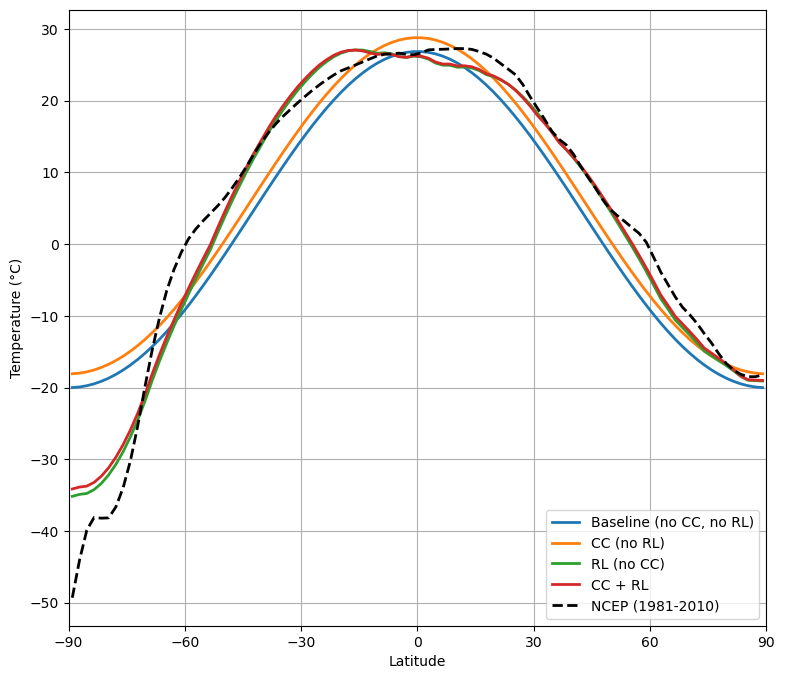

In [ ]:
fig = plt.figure(figsize=(9, 8)) ; ax = fig.gca()
ax.plot(ebm_baseline.lat, ebm_baseline.Ts, label="Baseline (no CC, no RL)", linewidth=2)
ax.plot(ebm_baseline.lat, ebm_cc.Ts, label="CC (no RL)", linewidth=2)
ax.plot(ebm_baseline.lat, ebm_nocc_state, label="RL (no CC)", linewidth=2)
ax.plot(ebm_baseline.lat, ebm_cc_state, label="CC + RL", linewidth=2)
ax.plot(ebm_baseline.lat, Ts_ncep_annual, label="NCEP (1981-2010)", linewidth=2, linestyle="dashed", color="k")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Latitude")
ax.set_xlim(-90, 90)
ax.set_xticks(np.arange(-90, 91, 30))
ax.legend()
ax.grid()

plotting_data = {
    "lat": np.asarray(ebm_baseline.lat).reshape(-1).tolist(),
    "baseline": np.asarray(ebm_baseline.Ts).reshape(-1).tolist(),
    "cc_no_rl": np.asarray(ebm_cc.Ts).reshape(-1).tolist(),
    "rl_no_cc": np.asarray(ebm_nocc_state).reshape(-1).tolist(),
    "cc_rl": np.asarray(ebm_cc_state).reshape(-1).tolist(),
    "ncep": Ts_ncep_annual.values.reshape(-1).tolist(),
}

for ext in ["pdf", "png"]:
    plt.savefig(
        f"{IMGS_DIR}/{ext}/{EXP_ID}_delta_alpha-{DELTA_A}_temp_profile.{ext}",
        dpi=300,
        bbox_inches="tight",
    )

plotting_data_path = (
    f"{PLOTTING_DATA_DIR}/{EXP_ID}_delta_alpha-{DELTA_A}_temp_profile.json"
)
with open(plotting_data_path, "w", encoding="utf-8") as fh:
    json.dump(plotting_data, fh, indent=4)

